<a href="https://colab.research.google.com/github/yiqi0806-collab/Sensitive-annlysis/blob/main/Filtration_model_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#### GAS gaussian-quad 新版更正代码
from typing import Callable, Optional
from scipy.special import roots_legendre
import numpy as np
import numpy.random as R
import time
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
from scipy.integrate import newton_cotes
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline
from scipy.integrate import solve_ivp, simpson

def _gauss_legendre_01(n: int):
    # GL on (0,1): map (-1,1) -> (0,1)
    t, w = roots_legendre(n)
    s = 0.5*(t + 1.0)     # nodes in (0,1)
    w = 0.5*w             # sum to 1
    return s, w

def calc_C(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 10,
    g: Optional[Callable[[np.ndarray], np.ndarray]] = None,  # 边缘密度；均匀时可缺省
    return_AS: bool = False,  # 如需调试可顺带返回 A,S
    clip_eps: float = 1e-12   # 数值误差矫正
):
    """
    直接返回“正确的”敏感度矩阵 C（对称 PSD）：
      - 对角: E_z[ ∫ q_i(v;z)^2 dv ]
      - 非对角: E_z[ (∫ q_i dv)(∫ q_j dv) ]
    不增加任何 f 调用；只在同一批节点上额外做了平方与加权。
    """
    M, d = X.shape
    A = np.zeros((M, d), dtype=float)   # A[i,j] = ∫ q_i dv  （非对角用）
    S = np.zeros((M, d), dtype=float)   # S[i,j] = ∫ q_i^2 dv（对角用）

    s_nodes, s_w = _gauss_legendre_01(n_points)
    f_z = f(X)                          # 基点 f(z) 只算一次

    for i in range(M):
        z  = X[i]
        fz = f_z[i]

        for j in range(d):
            zj = z[j]

            # --- 左段 v ∈ [0, z_j],  v = z_j * s  ---
            if zj > 0.0:
                eval_left = np.tile(z, (n_points, 1))
                eval_left[:, j] = zj * s_nodes
                f_left = f(eval_left)                 # 复用：不重复算

                vL = eval_left[:, j]
                qL = (f_left - fz) / (vL - zj)        # q = (f(v)-f(z)) / (v - z_j)

                gL = 1.0 if g is None else g(vL)
                JL = zj                               # dv = z_j ds

                A[i, j] += np.dot(qL,        s_w) * JL * gL
                S[i, j] += np.dot(qL * qL,   s_w) * JL * gL

            # --- 右段 v ∈ [z_j, 1],  v = z_j + (1-z_j) * s ---
            if zj < 1.0:
                eval_right = np.tile(z, (n_points, 1))
                eval_right[:, j] = zj + (1.0 - zj) * s_nodes
                f_right = f(eval_right)

                vR = eval_right[:, j]
                qR = (f_right - fz) / (vR - zj)

                gR = 1.0 if g is None else g(vR)
                JR = (1.0 - zj)

                A[i, j] += np.dot(qR,        s_w) * JR * gR
                S[i, j] += np.dot(qR * qR,   s_w) * JR * gR

    # 组装 C：先用 A^T A / M 放非对角，再用 S 的均值替换对角
    C = (A.T @ A) / M
    np.fill_diagonal(C, S.mean(axis=0))

    # 数值对称化 + 夹小负值到 0（避免舍入误差破坏 PSD）
    C = 0.5 * (C + C.T)
    w, _ = np.linalg.eigh(C)
    if w.min() < -clip_eps:
        # 仅当你特别在意 PSD，可用投影法强制 PSD；默认仅做微小裁剪
        C[np.diag_indices_from(C)] = np.maximum(np.diag(C), 0.0)

    return (C, A, S) if return_AS else C

def dFunc0(x,Func,M2,shiftedSobol=True,distribution='uniform'):    #rememebr to change distribution if not use shiftedSobol
    chi,dim = x.shape[0],x.shape[1]
    temp = np.zeros((dim,chi*M2))
    #print("55555",x)
    if(shiftedSobol == True):
        rand_add = qmc.Sobol(dim, scramble=False).random(M2+1)[1:]
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = norm.ppf((norm.cdf(x)+rand_add[i])%1)
            elif distribution == 'uniform':
                rand = (x+rand_add[i])%1
            elif distribution =='chi_squared':
                rand1 = chi2.ppf((chi2.cdf(x[:,0],df=10)+rand_add[i][0])%1, df=10)
                rand2 = chi2.ppf((chi2.cdf(x[:,1],df=13.978)+rand_add[i][1])%1, df=13.978)
                rand = np.column_stack((rand1, rand2))
            #print("22222",rand)
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("11111",xe)
            #xe += rand.T * np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("55555",x.shape)
            #print("66666",Func(xe).shape)
            #print("77777",Func(x).shape)
            #print("8888",np.tile(Func(x),dim).shape)
            #print("101010",np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1).reshape(dim,chi))
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    else:
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = R.normal(0,1,(chi,dim))
            elif distribution == 'uniform':
                rand = R.uniform(0,1,(chi,dim))
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    return temp

# Calculate eigenvalue decomposition //Func in put is m*n matrix, where n is the dimension of x of f(x), m is how many sample to repeat for x 比如100*10 100个x 每个x是10dimension.
#                     output is m number of result f(x)
def GAS(Func,dim,chi,M1,M2,shiftedSobol=True,distribution='uniform'):      #remember to change distribution
    if distribution == 'normal':
        z = R.normal(0, 1, (M1, dim))
    elif distribution == 'uniform':
        z = R.uniform(0, 1, (M1, dim))
        #for i, parameters in enumerate(z):
          #a=solve_and_integrate(parameters,10)
          #while a<28402714.35 or a>276499908.09:
            #z[i] = R.uniform(0, 1, (1, dim))
            #a=solve_and_integrate(parameters,10)
    elif distribution == 'chi_squared':                 #special case for chi_squared
        x1_samples = R.chisquare(df=10, size=M1)
        x2_samples = R.chisquare(df=13.978, size=M1)
        z = np.column_stack((x1_samples, x2_samples))
    deriv = dFunc0(z,Func,M2,shiftedSobol,distribution=distribution)
    deriv /= np.sqrt(chi)
    u, s, vh = np.linalg.svd(deriv.astype(float), full_matrices=True)
    s = s**2
    return u, s



# Estimate the matrix Phi
def Phi_est(X, expo, coef, P):
    Num = X.shape[0]
    dim = X.shape[1]
    return np.dot(np.prod((np.tile(X, P)**expo.flatten()).reshape((Num*P, dim)),axis = 1).reshape((Num, P))
               ,np.array(coef)).T

def Funy(z,z1,u,Func):
    dim = u.shape[0]
    dim1 = z.shape[1]
    chi = z.shape[0]
    f1 = Func(np.dot(z,u[:,:dim1].transpose())+np.dot(z1,u[:,dim1:].transpose()))
    return f1

# Estimate k hat
def estimate_k_reg1(z,z1,u, exponents, coefficients, P, Func):
    phi = Phi_est(z, exponents, coefficients,P)
    khat = np.linalg.inv(phi @ np.transpose(phi)) @ phi @ Funy(z,z1,u,Func)
    return khat

# Estimate the expectation from PCE
def GAS_PCE(Func, Num_exp, z1, dim1, u, exponents, coefficients, P):
    PCE = np.zeros(Num_exp)
    for i in range(Num_exp):
        kii = estimate_k_reg1(z1[i][:,:dim1], z1[i][:,dim1:], u, exponents, coefficients, P, Func)
        PCE[i] = kii[0]
    return PCE

def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score

def solve_and_integrate(parameters,n):
    K, p, mu, Rm, v, T, K_hat, r= parameters
    K=K*(1.3-0.7)*3.5+0.7*3.5
    p=p*(1.3-0.7)*2+0.7*2
    mu=mu*(1.3-0.7)*0.5+0.7*0.5
    Rm=Rm*(1.3-0.7)*1+0.7*1
    v=v*(1.3-0.7)*1+0.7*1
    T=T*(1.3-0.7)*5+0.7*5
    K_hat=K_hat*(1.3-0.7)*43+0.7*43
    r=r*(1.3-0.7)*0.7+0.7*0.7


    # Define the ODE systems
    def ode_system_1(t, B):
        return K * p / (mu * (Rm + v * B))

    def ode_system_2(t, B):
        return -K_hat * p * B / (mu * (Rm + v * B))

    # Define the ODE systems
    #def ode_system_1(t, B):
     #   val=(K * p / (mu * (Rm + v * B)))
      #  return val + np.random.normal(loc=0, scale=abs(val)*0.2)                      ## add noisy with N(0,#% of answer)
    #def ode_system_2(t, B):
     #   val=(-K_hat * p * B / (mu * (Rm + v * B)))
      #  return val + np.random.normal(loc=0, scale=abs(val)*0.2)                      ## add noisy with N(0,#% of answer)


    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

def percentage_within_std_range(numbers, std_range=1):
    mean_val = np.mean(numbers)  # Compute the mean
    std_dev = np.std(numbers, ddof=1)  # Compute standard deviation

    # Define the statistical range
    lower_bound = mean_val - std_range * std_dev
    upper_bound = mean_val + std_range * std_dev

    # Count numbers within the range
    within_range = [num for num in numbers if lower_bound <= num <= upper_bound]
    percentage_within = (len(within_range) / len(numbers)) * 100

    return {
        "mean": mean_val,
        "std_dev": std_dev,
        "range": (lower_bound, upper_bound),
        "percentage_within": percentage_within,
        "total_values": len(numbers),
        "values_within_range": len(within_range)
    }


def Func(x):
  results = []
  for i, parameters in enumerate(x):
    #print("index is",i)
    results.append(solve_and_integrate(parameters,10))
  results = np.array(results)

    # Plot the results inside Func
  #plt.figure(figsize=(10, 5))
  #plt.plot(range(len(results)), results, marker='o', linestyle='-', color='b', label="Func Output")
  #plt.xlabel("Sample Index")
  #plt.ylabel("Function Output")
  #plt.title("Plot of Func(x) Output Values")
  #plt.legend()
  #plt.grid(True)
  #plt.show()

  #result = percentage_within_std_range(results, std_range=2)  # Using ±2 standard deviations (95%)

  ## Print results
  #print("Mean:", result["mean"])
  #print("Standard Deviation:", result["std_dev"])
  #print("Accepted Range:", result["range"])
  #print("Percentage Within Range:", result["percentage_within"], "%")
  return np.array(results)

Time: 4184.0135461889995 seconds


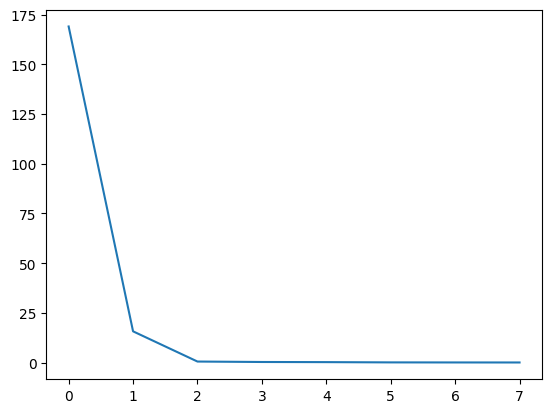

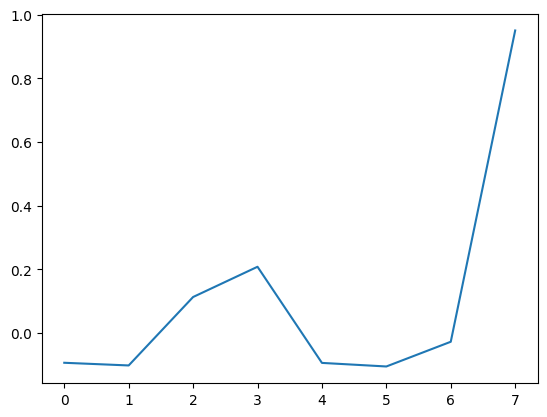

The parameter order is :K, p, mu, Rm, v, T, K_hat, r
GAS_score is [8.61299392e-03 2.88417627e-02 3.45913781e-02 5.57354791e-02
 8.67847388e-03 3.04106164e-02 7.04073324e-04 8.32425223e-01]
K is: 0.008612993920951316
p is: 0.02884176266380662
mu is: 0.03459137814348015
Rm is: 0.05573547913163244
v is: 0.00867847387940928
T is: 0.030410616372853357
K_hat is: 0.0007040733239696305
r is: 0.8324252225638973


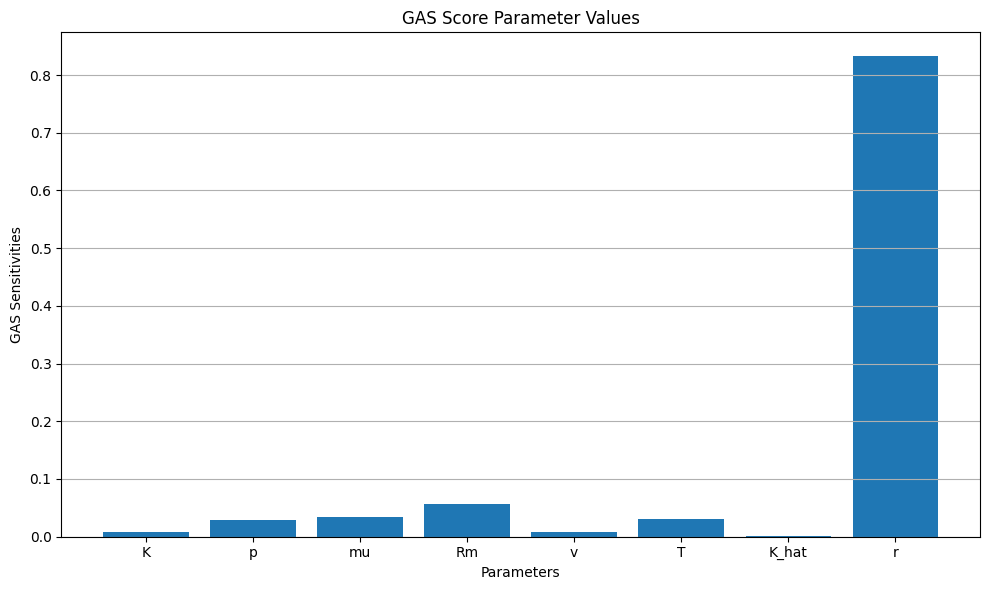

In [ ]:
start = time.perf_counter()
dim=8
chi=10000
M2 = 5
C = calc_C(
            f=Func,
            X=R.uniform(0, 1, (int(chi/2/M2), dim)),
            n_points=M2
        )
#print("55555",C.shape)
#u, s, _ = np.linalg.svd(C.T.astype(float), full_matrices=False)

#gas_values8 = GAS_score(8, u, s)
#gas_values = GAS_score(1, u, s)

C = 0.5 * (C + C.T)                 # 数值对称
s, u = np.linalg.eigh(C)            # s 升序，u 的第 i 列 ↔ s[i]

# 需要降序：
idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

# 交给 GAS
gas_values  = GAS_score(2, u, s)
end = time.perf_counter()
print("Time:", end - start, "seconds")

plt.plot(s)
plt.show()

plt.plot(u[:,0])
plt.show()

# Print the values
print("The parameter order is :K, p, mu, Rm, v, T, K_hat, r")
print("GAS_score is",gas_values)
print("K is:",gas_values[0])
print("p is:",gas_values[1])
print("mu is:",gas_values[2])
print("Rm is:",gas_values[3])
print("v is:",gas_values[4])
print("T is:",gas_values[5])
print("K_hat is:",gas_values[6])
print("r is:",gas_values[7])


# 参数标签
parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat", "r"]
x = np.arange(len(parameters))

# 绘制并排柱状图
plt.figure(figsize=(10, 6))
plt.bar(x, gas_values)
plt.xlabel("Parameters")
plt.ylabel("GAS Sensitivities")
plt.title("GAS Score Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 16.8 MB/s eta 0:00:00


/tmp/ipython-input-2980670718.py:91: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=False)
/usr/local/lib/python3.12/dist-packages/SALib/sample/saltelli.py:110: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (10000) is equal to `2^n`.
        
  warnings.warn(msg)


Time: 5078.965927644 seconds
Total Sobol Indices:
K: 0.0097
p: 0.0325
mu: 0.0355
Rm: 0.0578
v: 0.0098
T: 0.0319
K_hat: 0.0008
r: 0.9236


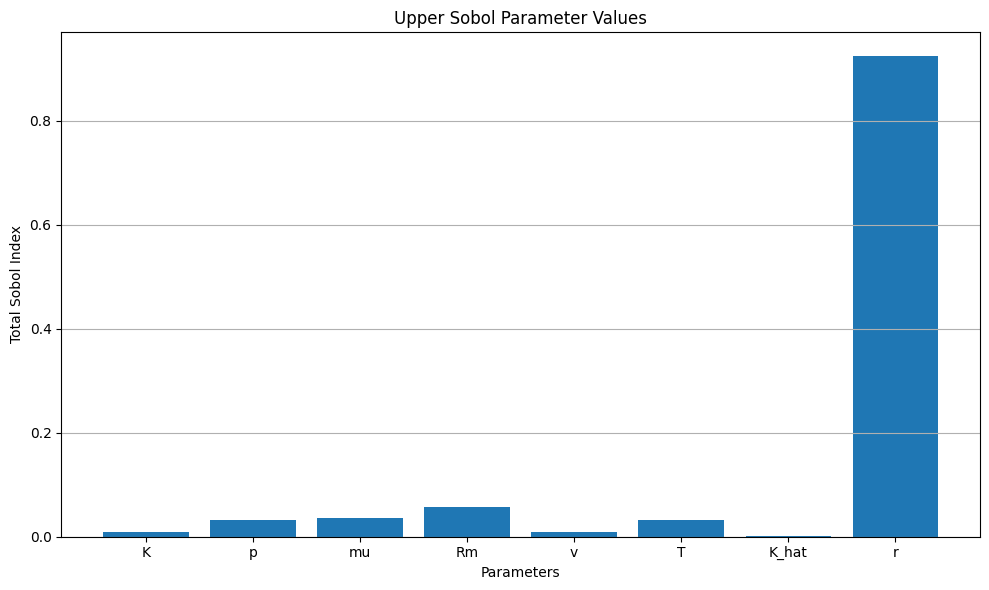

In [ ]:
import numpy as np
!pip install SALib
import time
import SALib
from SALib.sample import saltelli
from SALib.analyze import sobol
import matplotlib.pyplot as plt

def function1(parameters,n):
    K, p, mu, Rm, v, T, K_hat, r= parameters

    # Define the ODE systems
    def ode_system_1(t, B):
        return K * p / (mu * (Rm + v * B))

    def ode_system_2(t, B):
        return -K_hat * p * B / (mu * (Rm + v * B))

    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

start = time.perf_counter()

problem = {
    'num_vars': 8,
    'names': ['K', 'p', 'mu', 'Rm', 'v', 'T', 'K_hat', 'r'],
    'bounds': [
        [0.7 * 3.5, 1.3 * 3.5],    # K
        [0.7 * 2, 1.3 * 2],            # p
        [0.7 * 0.5, 1.3 * 0.5],  # mu
        [0.7 * 1, 1.3 * 1],  # Rm
        [0.7 * 1, 1.3 * 1],  # v
        [0.7 * 5, 1.3 * 5],            # T
        [0.7 * 43, 1.3 * 43],      # K_hat
        [0.7 * 0.7, 1.3 * 0.7]         # r
    ]
}

# Generate samples using Saltelli's sampling method
N = 10000  # Base sample size
param_values = saltelli.sample(problem, N, calc_second_order=False)

# Evaluate the model for each sample with n=10
Y = np.array([function1(params, n=10) for params in param_values])

# Perform Sobol sensitivity analysis
Si = sobol.analyze(problem, Y, calc_second_order=False)

end = time.perf_counter()
print("Time:", end - start, "seconds")

# Print Total Sobol Indices (upper indices)
print("Total Sobol Indices:")
for i, param in enumerate(problem['names']):
    print(f"{param}: {Si['ST'][i]:.4f}")

# Plot the total Sobol indices as a bar chart
# 参数标签
parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat", "r"]
x = np.arange(len(parameters))

plt.figure(figsize=(10, 6))
plt.bar(x, Si['ST'])
plt.xlabel("Parameters")
plt.ylabel("Total Sobol Index")
plt.title("Upper Sobol Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

               vi      vi_std      dgsm  dgsm_conf
K        1.734079    1.586184  0.012697   0.030355
p        5.422170    9.180886  0.039700   0.194659
mu       7.231398   16.644640  0.052947   0.287575
Rm      12.191045   25.065935  0.089260   0.553999
v        1.734921    1.588512  0.012703   0.028082
T        5.420800    9.148857  0.039690   0.157810
K_hat    0.160265    0.197921  0.001173   0.003988
r      151.902196  102.865722  1.112192   1.907661
Time: 4185.742818631999 seconds


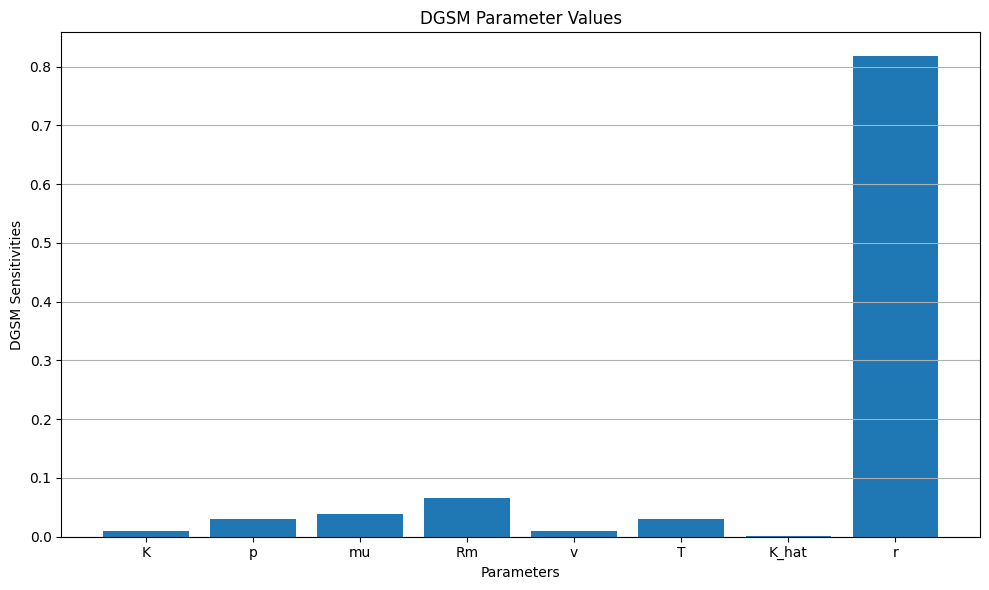

In [ ]:
import numpy as np
!pip install SALib
import SALib
import time
import matplotlib.pyplot as plt
from SALib.analyze import dgsm
from SALib.sample import finite_diff
from scipy.integrate import solve_ivp, simpson



def function2(parameters,n):
    K, p, mu, Rm, v, T, K_hat, r= parameters
    #K=K*(1.3-0.7)*10**9+0.7*10**9
    #p=p*(1.3-0.7)*2+0.7*2
    #mu=mu*(1.3-0.7)*10**(-3)+0.7*10**(-3)
    #Rm=Rm*(1.3-0.7)*10**(-7)+0.7*10**(-7)
    #v=v*(1.3-0.7)*10**(-5)+0.7*10**(-5)
    #T=T*(1.3-0.7)*5+0.7*5
    #K_hat=K_hat*(1.3-0.7)*0.01+0.7*0.01
    #r=r*(1.3-0.7)*0.7+0.7*0.7

    K=K*(1.3-0.7)*3.5+0.7*3.5
    p=p*(1.3-0.7)*2+0.7*2
    mu=mu*(1.3-0.7)*0.5+0.7*0.5
    Rm=Rm*(1.3-0.7)*1+0.7*1
    v=v*(1.3-0.7)*1+0.7*1
    T=T*(1.3-0.7)*5+0.7*5
    K_hat=K_hat*(1.3-0.7)*43+0.7*43
    r=r*(1.3-0.7)*0.7+0.7*0.7

    # Define the ODE systems
    def ode_system_1(t, B):
        return K * p / (mu * (Rm + v * B))

    def ode_system_2(t, B):
        return -K_hat * p * B / (mu * (Rm + v * B))

    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

start = time.perf_counter()
# Define the parameter bounds
#bounds = np.array([
#    [0.7 * 3.5, 1.3 * 3.5],    # K
#    [0.7 * 2, 1.3 * 2],            # p
#    [0.7 * 0.5, 1.3 * 0.5],  # mu
#    [0.7 * 1, 1.3 * 1],  # Rm
#    [0.7 * 1, 1.3 * 1],  # v
#    [0.7 * 5, 1.3 * 5],            # T
#    [0.7 * 43, 1.3 * 43],      # K_hat
#    [0.7 * 0.7, 1.3 * 0.7]         # r
#])

#bounds = np.array([
#    [0.7 * 10**9, 1.3 * 10**9],    # K
#    [0.7 * 2, 1.3 * 2],            # p
#    [0.7 * 10**(-3), 1.3 * 10**(-3)],  # mu
#    [0.7 * 10**(-7), 1.3 * 10**(-7)],  # Rm
#    [0.7 * 10**(-5), 1.3 * 10**(-5)],  # v
#    [0.7 * 5, 1.3 * 5],            # T
#    [0.7 * 0.01, 1.3 * 0.01],      # K_hat
#    [0.7 * 0.7, 1.3 * 0.7]         # r
#])

bounds = np.array([
    [0,1],    # K
    [0,1],            # p
    [0,1],  # mu
    [0,1],  # Rm
    [0,1],  # v
    [0,1],            # T
    [0,1],      # K_hat
    [0,1]         # r
])

# Define the problem dictionary required by SALib
problem = {
    'num_vars': len(bounds),
    'names': ['K', 'p', 'mu', 'Rm', 'v', 'T', 'K_hat', 'r'],
    'bounds': bounds.tolist()
}

N=10000
# Generate samples using finite difference method
param_values = finite_diff.sample(problem, N)

# Compute the function output for each sample
Y = np.array([function2(params,n=10) for params in param_values])

# Perform DGSM analysis
dgsm_results = dgsm.analyze(problem, param_values, Y, print_to_console=True)

# Normalize
vi = dgsm_results['vi']
vi_normalized = vi / np.sum(vi)
end = time.perf_counter()
print("Time:", end - start, "seconds")

parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat", "r"]
x = np.arange(len(parameters))

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x, vi_normalized)
plt.xlabel("Parameters")
plt.ylabel("DGSM Sensitivities")
plt.title("DGSM Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.tight_layout()
plt.show()



In [ ]:
#### GAS gaussian-quad 新版更正代码 fix r
from typing import Callable, Optional
from scipy.special import roots_legendre
import numpy as np
import numpy.random as R
import time
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
from scipy.integrate import newton_cotes
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline
from scipy.integrate import solve_ivp, simpson

def _gauss_legendre_01(n: int):
    # GL on (0,1): map (-1,1) -> (0,1)
    t, w = roots_legendre(n)
    s = 0.5*(t + 1.0)     # nodes in (0,1)
    w = 0.5*w             # sum to 1
    return s, w

def calc_C(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 10,
    g: Optional[Callable[[np.ndarray], np.ndarray]] = None,  # 边缘密度；均匀时可缺省
    return_AS: bool = False,  # 如需调试可顺带返回 A,S
    clip_eps: float = 1e-12   # 数值误差矫正
):
    """
    直接返回“正确的”敏感度矩阵 C（对称 PSD）：
      - 对角: E_z[ ∫ q_i(v;z)^2 dv ]
      - 非对角: E_z[ (∫ q_i dv)(∫ q_j dv) ]
    不增加任何 f 调用；只在同一批节点上额外做了平方与加权。
    """
    M, d = X.shape
    A = np.zeros((M, d), dtype=float)   # A[i,j] = ∫ q_i dv  （非对角用）
    S = np.zeros((M, d), dtype=float)   # S[i,j] = ∫ q_i^2 dv（对角用）

    s_nodes, s_w = _gauss_legendre_01(n_points)
    f_z = f(X)                          # 基点 f(z) 只算一次

    for i in range(M):
        z  = X[i]
        fz = f_z[i]

        for j in range(d):
            zj = z[j]

            # --- 左段 v ∈ [0, z_j],  v = z_j * s  ---
            if zj > 0.0:
                eval_left = np.tile(z, (n_points, 1))
                eval_left[:, j] = zj * s_nodes
                f_left = f(eval_left)                 # 复用：不重复算

                vL = eval_left[:, j]
                qL = (f_left - fz) / (vL - zj)        # q = (f(v)-f(z)) / (v - z_j)

                gL = 1.0 if g is None else g(vL)
                JL = zj                               # dv = z_j ds

                A[i, j] += np.dot(qL,        s_w) * JL * gL
                S[i, j] += np.dot(qL * qL,   s_w) * JL * gL

            # --- 右段 v ∈ [z_j, 1],  v = z_j + (1-z_j) * s ---
            if zj < 1.0:
                eval_right = np.tile(z, (n_points, 1))
                eval_right[:, j] = zj + (1.0 - zj) * s_nodes
                f_right = f(eval_right)

                vR = eval_right[:, j]
                qR = (f_right - fz) / (vR - zj)

                gR = 1.0 if g is None else g(vR)
                JR = (1.0 - zj)

                A[i, j] += np.dot(qR,        s_w) * JR * gR
                S[i, j] += np.dot(qR * qR,   s_w) * JR * gR

    # 组装 C：先用 A^T A / M 放非对角，再用 S 的均值替换对角
    C = (A.T @ A) / M
    np.fill_diagonal(C, S.mean(axis=0))

    # 数值对称化 + 夹小负值到 0（避免舍入误差破坏 PSD）
    C = 0.5 * (C + C.T)
    w, _ = np.linalg.eigh(C)
    if w.min() < -clip_eps:
        # 仅当你特别在意 PSD，可用投影法强制 PSD；默认仅做微小裁剪
        C[np.diag_indices_from(C)] = np.maximum(np.diag(C), 0.0)

    return (C, A, S) if return_AS else C

def dFunc0(x,Func,M2,shiftedSobol=True,distribution='uniform'):    #rememebr to change distribution if not use shiftedSobol
    chi,dim = x.shape[0],x.shape[1]
    temp = np.zeros((dim,chi*M2))
    #print("55555",x)
    if(shiftedSobol == True):
        rand_add = qmc.Sobol(dim, scramble=False).random(M2+1)[1:]
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = norm.ppf((norm.cdf(x)+rand_add[i])%1)
            elif distribution == 'uniform':
                rand = (x+rand_add[i])%1
            elif distribution =='chi_squared':
                rand1 = chi2.ppf((chi2.cdf(x[:,0],df=10)+rand_add[i][0])%1, df=10)
                rand2 = chi2.ppf((chi2.cdf(x[:,1],df=13.978)+rand_add[i][1])%1, df=13.978)
                rand = np.column_stack((rand1, rand2))
            #print("22222",rand)
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("11111",xe)
            #xe += rand.T * np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("55555",x.shape)
            #print("66666",Func(xe).shape)
            #print("77777",Func(x).shape)
            #print("8888",np.tile(Func(x),dim).shape)
            #print("101010",np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1).reshape(dim,chi))
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    else:
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = R.normal(0,1,(chi,dim))
            elif distribution == 'uniform':
                rand = R.uniform(0,1,(chi,dim))
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    return temp

# Calculate eigenvalue decomposition //Func in put is m*n matrix, where n is the dimension of x of f(x), m is how many sample to repeat for x 比如100*10 100个x 每个x是10dimension.
#                     output is m number of result f(x)
def GAS(Func,dim,chi,M1,M2,shiftedSobol=True,distribution='uniform'):      #remember to change distribution
    if distribution == 'normal':
        z = R.normal(0, 1, (M1, dim))
    elif distribution == 'uniform':
        z = R.uniform(0, 1, (M1, dim))
        #for i, parameters in enumerate(z):
          #a=solve_and_integrate(parameters,10)
          #while a<28402714.35 or a>276499908.09:
            #z[i] = R.uniform(0, 1, (1, dim))
            #a=solve_and_integrate(parameters,10)
    elif distribution == 'chi_squared':                 #special case for chi_squared
        x1_samples = R.chisquare(df=10, size=M1)
        x2_samples = R.chisquare(df=13.978, size=M1)
        z = np.column_stack((x1_samples, x2_samples))
    deriv = dFunc0(z,Func,M2,shiftedSobol,distribution=distribution)
    deriv /= np.sqrt(chi)
    u, s, vh = np.linalg.svd(deriv.astype(float), full_matrices=True)
    s = s**2
    return u, s



# Estimate the matrix Phi
def Phi_est(X, expo, coef, P):
    Num = X.shape[0]
    dim = X.shape[1]
    return np.dot(np.prod((np.tile(X, P)**expo.flatten()).reshape((Num*P, dim)),axis = 1).reshape((Num, P))
               ,np.array(coef)).T

def Funy(z,z1,u,Func):
    dim = u.shape[0]
    dim1 = z.shape[1]
    chi = z.shape[0]
    f1 = Func(np.dot(z,u[:,:dim1].transpose())+np.dot(z1,u[:,dim1:].transpose()))
    return f1

# Estimate k hat
def estimate_k_reg1(z,z1,u, exponents, coefficients, P, Func):
    phi = Phi_est(z, exponents, coefficients,P)
    khat = np.linalg.inv(phi @ np.transpose(phi)) @ phi @ Funy(z,z1,u,Func)
    return khat

# Estimate the expectation from PCE
def GAS_PCE(Func, Num_exp, z1, dim1, u, exponents, coefficients, P):
    PCE = np.zeros(Num_exp)
    for i in range(Num_exp):
        kii = estimate_k_reg1(z1[i][:,:dim1], z1[i][:,dim1:], u, exponents, coefficients, P, Func)
        PCE[i] = kii[0]
    return PCE

def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score

def solve_and_integrate(parameters,n):
    K, p, mu, Rm, v, T, K_hat= parameters
    K=K*(1.1-0.9)*3.5+0.7*3.5
    p=p*(1.1-0.9)*2+0.7*2
    mu=mu*(1.1-0.9)*0.5+0.7*0.5
    Rm=Rm*(1.1-0.9)*1+0.7*1
    v=v*(1.1-0.9)*1+0.7*1
    T=T*(1.1-0.9)*5+0.7*5
    K_hat=K_hat*(1.1-0.9)*43+0.7*43

    r=0.7


    # Define the ODE systems
    def ode_system_1(t, B):
        return K * p / (mu * (Rm + v * B))

    def ode_system_2(t, B):
        return -K_hat * p * B / (mu * (Rm + v * B))

    # Define the ODE systems
    #def ode_system_1(t, B):
     #   val=(K * p / (mu * (Rm + v * B)))
      #  return val + np.random.normal(loc=0, scale=abs(val)*0.2)                      ## add noisy with N(0,#% of answer)
    #def ode_system_2(t, B):
     #   val=(-K_hat * p * B / (mu * (Rm + v * B)))
      #  return val + np.random.normal(loc=0, scale=abs(val)*0.2)                      ## add noisy with N(0,#% of answer)


    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

def percentage_within_std_range(numbers, std_range=1):
    mean_val = np.mean(numbers)  # Compute the mean
    std_dev = np.std(numbers, ddof=1)  # Compute standard deviation

    # Define the statistical range
    lower_bound = mean_val - std_range * std_dev
    upper_bound = mean_val + std_range * std_dev

    # Count numbers within the range
    within_range = [num for num in numbers if lower_bound <= num <= upper_bound]
    percentage_within = (len(within_range) / len(numbers)) * 100

    return {
        "mean": mean_val,
        "std_dev": std_dev,
        "range": (lower_bound, upper_bound),
        "percentage_within": percentage_within,
        "total_values": len(numbers),
        "values_within_range": len(within_range)
    }


def Func(x):
  results = []
  for i, parameters in enumerate(x):
    #print("index is",i)
    results.append(solve_and_integrate(parameters,10))
  results = np.array(results)
  return np.array(results)

Time: 3088.0265714270004 seconds


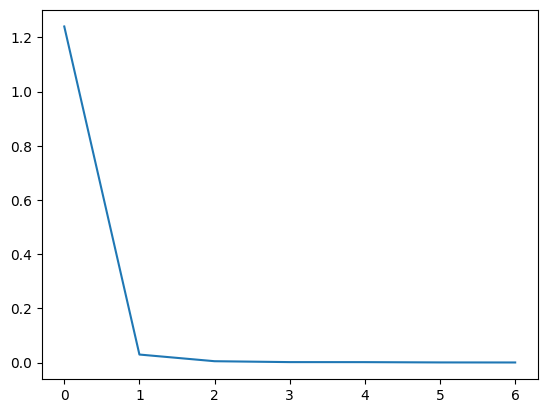

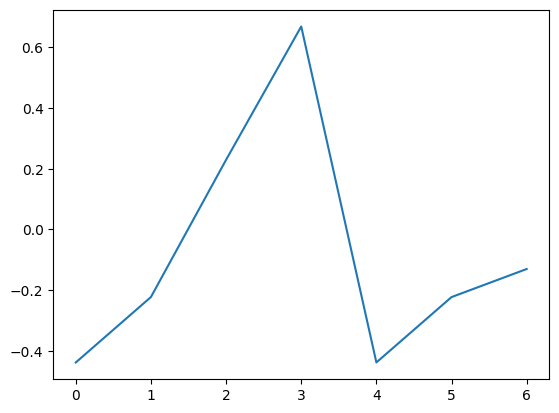

The parameter order is :K, p, mu, Rm, v, T, K_hat
GAS_score is [0.19092655 0.05349724 0.05734939 0.43728356 0.19075693 0.0535605
 0.01662583]
K is: 0.1909265475933263
p is: 0.053497237034798584
mu is: 0.057349391204922495
Rm is: 0.43728356196190127
v is: 0.1907569287411098
T is: 0.05356050208317792
K_hat is: 0.01662583138076358


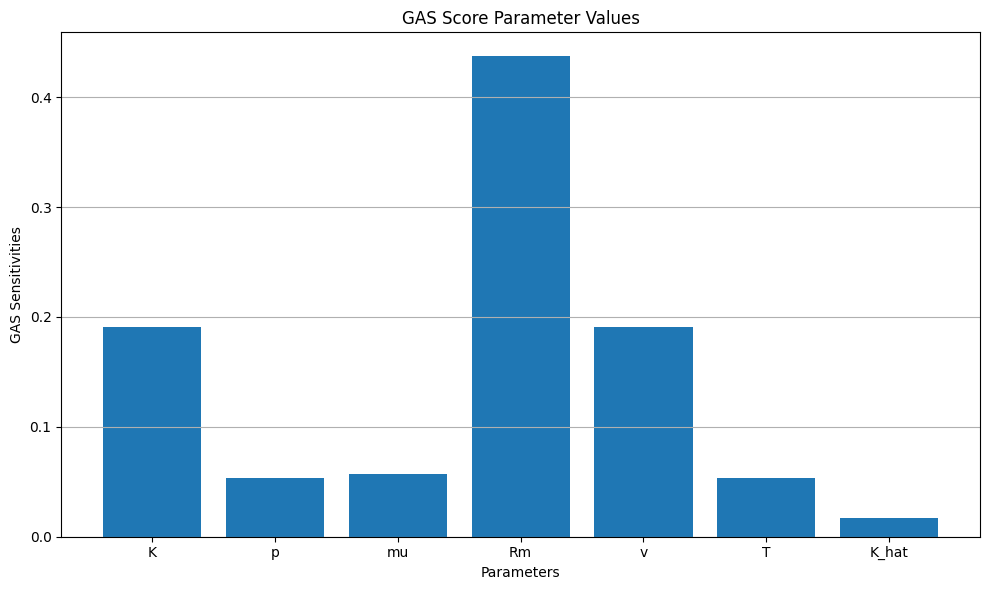

In [ ]:
start = time.perf_counter()
dim=7
chi=10000
M2 = 5
C = calc_C(
            f=Func,
            X=R.uniform(0, 1, (int(chi/2/M2), dim)),
            n_points=M2
        )

C = 0.5 * (C + C.T)                 # 数值对称
s, u = np.linalg.eigh(C)            # s 升序，u 的第 i 列 ↔ s[i]

# 需要降序：
idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

# 交给 GAS
gas_values  = GAS_score(3, u, s)
end = time.perf_counter()
print("Time:", end - start, "seconds")

plt.plot(s)
plt.show()

plt.plot(u[:,0])
plt.show()

# Print the values
print("The parameter order is :K, p, mu, Rm, v, T, K_hat")
print("GAS_score is",gas_values)
print("K is:",gas_values[0])
print("p is:",gas_values[1])
print("mu is:",gas_values[2])
print("Rm is:",gas_values[3])
print("v is:",gas_values[4])
print("T is:",gas_values[5])
print("K_hat is:",gas_values[6])



# 参数标签
parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat"]
x = np.arange(len(parameters))

# 绘制并排柱状图
plt.figure(figsize=(10, 6))
plt.bar(x, gas_values)
plt.xlabel("Parameters")
plt.ylabel("GAS Sensitivities")
plt.title("GAS Score Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 29.0 MB/s eta 0:00:00


/tmp/ipython-input-2833075167.py:90: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=False)
/usr/local/lib/python3.12/dist-packages/SALib/sample/saltelli.py:110: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (10000) is equal to `2^n`.
        
  warnings.warn(msg)


Time: 7217.498396782 seconds
Total Sobol Indices:
K: 0.1484
p: 0.0853
mu: 0.0868
Rm: 0.4545
v: 0.1483
T: 0.0851
K_hat: 0.0115


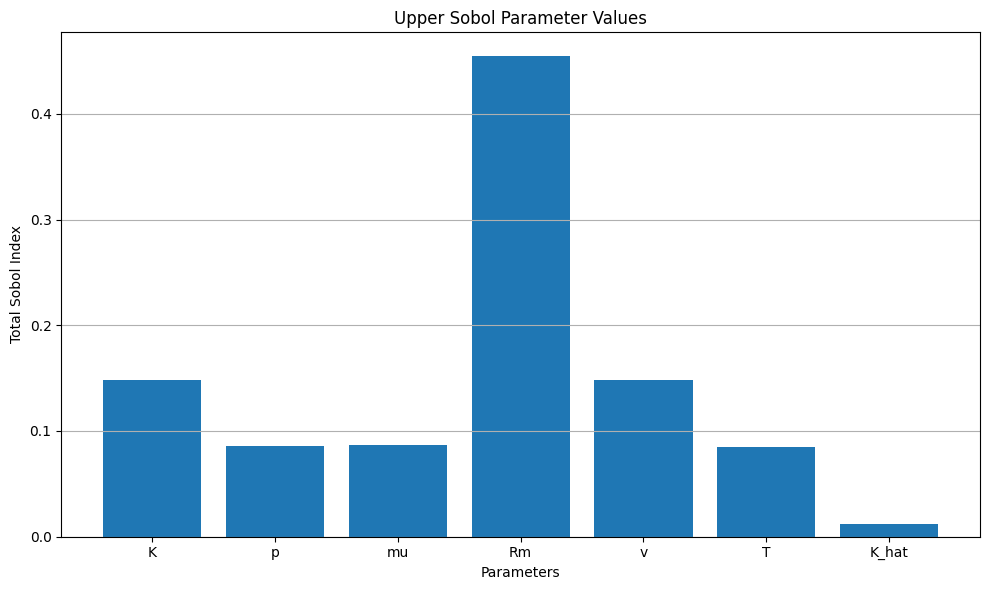

In [ ]:
import numpy as np
!pip install SALib
import SALib
from SALib.sample import saltelli
from SALib.analyze import sobol
import matplotlib.pyplot as plt

def function1(parameters,n):
    K, p, mu, Rm, v, T, K_hat= parameters

    r=0.7

    # Define the ODE systems
    def ode_system_1(t, B):
        return K * p / (mu * (Rm + v * B))

    def ode_system_2(t, B):
        return -K_hat * p * B / (mu * (Rm + v * B))

    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

# Define the Sobol problem with updated bounds
problem = {
    'num_vars': 7,
    'names': ['K', 'p', 'mu', 'Rm', 'v', 'T', 'K_hat'],
    'bounds': [
        [0.9 * 3.5, 1.1 * 3.5],    # K
        [0.9 * 2, 1.1 * 2],            # p
        [0.9 * 0.5, 1.1 * 0.5],  # mu
        [0.9 * 1, 1.1 * 1],  # Rm
        [0.9 * 1, 1.1 * 1],  # v
        [0.9 * 5, 1.1 * 5],            # T
        [0.9 * 43, 1.1 * 43],      # K_hat
    ]
}

# Generate samples using Saltelli's sampling method
N = 10000  # Base sample size
param_values = saltelli.sample(problem, N, calc_second_order=False)

# Evaluate the model for each sample with n=10
Y = np.array([function1(params, n=10) for params in param_values])

# Perform Sobol sensitivity analysis
Si = sobol.analyze(problem, Y, calc_second_order=False)

end = time.perf_counter()
print("Time:", end - start, "seconds")

# Print Total Sobol Indices (upper indices)
print("Total Sobol Indices:")
for i, param in enumerate(problem['names']):
    print(f"{param}: {Si['ST'][i]:.4f}")

parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat"]
x = np.arange(len(parameters))

plt.figure(figsize=(10, 6))
plt.bar(x, Si['ST'])
plt.xlabel("Parameters")
plt.ylabel("Total Sobol Index")
plt.title("Upper Sobol Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

             vi    vi_std      dgsm  dgsm_conf
K      0.248577  0.081216  0.241607   0.001806
p      0.073163  0.076353  0.071111   0.001465
mu     0.081713  0.097097  0.079422   0.002142
Rm     0.598193  0.393853  0.581421   0.008105
v      0.248581  0.081249  0.241611   0.001656
T      0.073158  0.076307  0.071107   0.001519
K_hat  0.022372  0.009460  0.021745   0.000176
Time: 3643.3233290280004 seconds


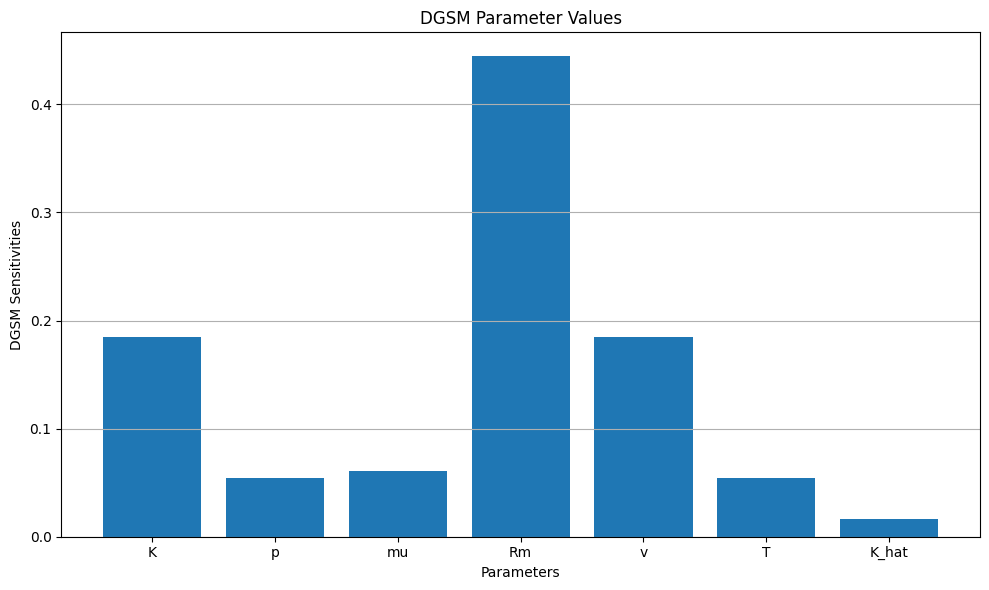

In [ ]:
import numpy as np
!pip install SALib
import SALib
import matplotlib.pyplot as plt
from SALib.analyze import dgsm
from SALib.sample import finite_diff


def function2(parameters,n):
    K, p, mu, Rm, v, T, K_hat= parameters
    #K=K*(1.3-0.7)*10**9+0.7*10**9
    #p=p*(1.3-0.7)*2+0.7*2
    #mu=mu*(1.3-0.7)*10**(-3)+0.7*10**(-3)
    #Rm=Rm*(1.3-0.7)*10**(-7)+0.7*10**(-7)
    #v=v*(1.3-0.7)*10**(-5)+0.7*10**(-5)
    #T=T*(1.3-0.7)*5+0.7*5
    #K_hat=K_hat*(1.3-0.7)*0.01+0.7*0.01
    #r=r*(1.3-0.7)*0.7+0.7*0.7

    K=K*(1.1-0.9)*3.5+0.7*3.5
    p=p*(1.1-0.9)*2+0.7*2
    mu=mu*(1.1-0.9)*0.5+0.7*0.5
    Rm=Rm*(1.1-0.9)*1+0.7*1
    v=v*(1.1-0.9)*1+0.7*1
    T=T*(1.1-0.9)*5+0.7*5
    K_hat=K_hat*(1.1-0.9)*43+0.7*43
    r=0.7

    # Define the ODE systems
    def ode_system_1(t, B):
        return K * p / (mu * (Rm + v * B))

    def ode_system_2(t, B):
        return -K_hat * p * B / (mu * (Rm + v * B))

    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

start = time.perf_counter()
bounds = np.array([
    [0,1],    # K
    [0,1],            # p
    [0,1],  # mu
    [0,1],  # Rm
    [0,1],  # v
    [0,1],            # T
    [0,1]      # K_hat
])

# Define the problem dictionary required by SALib
problem = {
    'num_vars': len(bounds),
    'names': ['K', 'p', 'mu', 'Rm', 'v', 'T', 'K_hat'],
    'bounds': bounds.tolist()
}

N=10000
# Generate samples using finite difference method
param_values = finite_diff.sample(problem, N)

# Compute the function output for each sample
Y = np.array([function2(params,n=10) for params in param_values])

# Perform DGSM analysis
dgsm_results = dgsm.analyze(problem, param_values, Y, print_to_console=True)

# Normalize
vi = dgsm_results['vi']
vi_normalized = vi / np.sum(vi)
end = time.perf_counter()
print("Time:", end - start, "seconds")

# Plot
parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat"]
x = np.arange(len(parameters))

plt.figure(figsize=(10, 6))
plt.bar(x, vi_normalized)
plt.xlabel("Parameters")
plt.ylabel("DGSM Sensitivities")
plt.title("DGSM Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
#### GAS gaussian-quad 新版更正代码 + NOISY
from typing import Callable, Optional
from scipy.special import roots_legendre
import numpy as np
import numpy.random as R
import time
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
from scipy.integrate import newton_cotes
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline
from scipy.integrate import solve_ivp, simpson

def _gauss_legendre_01(n: int):
    # GL on (0,1): map (-1,1) -> (0,1)
    t, w = roots_legendre(n)
    s = 0.5*(t + 1.0)     # nodes in (0,1)
    w = 0.5*w             # sum to 1
    return s, w

def calc_C(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 10,
    g: Optional[Callable[[np.ndarray], np.ndarray]] = None,  # 边缘密度；均匀时可缺省
    return_AS: bool = False,  # 如需调试可顺带返回 A,S
    clip_eps: float = 1e-12   # 数值误差矫正
):
    """
    直接返回“正确的”敏感度矩阵 C（对称 PSD）：
      - 对角: E_z[ ∫ q_i(v;z)^2 dv ]
      - 非对角: E_z[ (∫ q_i dv)(∫ q_j dv) ]
    不增加任何 f 调用；只在同一批节点上额外做了平方与加权。
    """
    M, d = X.shape
    A = np.zeros((M, d), dtype=float)   # A[i,j] = ∫ q_i dv  （非对角用）
    S = np.zeros((M, d), dtype=float)   # S[i,j] = ∫ q_i^2 dv（对角用）

    s_nodes, s_w = _gauss_legendre_01(n_points)
    f_z = f(X)                          # 基点 f(z) 只算一次

    for i in range(M):
        z  = X[i]
        fz = f_z[i]

        for j in range(d):
            zj = z[j]

            # --- 左段 v ∈ [0, z_j],  v = z_j * s  ---
            if zj > 0.0:
                eval_left = np.tile(z, (n_points, 1))
                eval_left[:, j] = zj * s_nodes
                f_left = f(eval_left)                 # 复用：不重复算

                vL = eval_left[:, j]
                qL = (f_left - fz) / (vL - zj)        # q = (f(v)-f(z)) / (v - z_j)

                gL = 1.0 if g is None else g(vL)
                JL = zj                               # dv = z_j ds

                A[i, j] += np.dot(qL,        s_w) * JL * gL
                S[i, j] += np.dot(qL * qL,   s_w) * JL * gL

            # --- 右段 v ∈ [z_j, 1],  v = z_j + (1-z_j) * s ---
            if zj < 1.0:
                eval_right = np.tile(z, (n_points, 1))
                eval_right[:, j] = zj + (1.0 - zj) * s_nodes
                f_right = f(eval_right)

                vR = eval_right[:, j]
                qR = (f_right - fz) / (vR - zj)

                gR = 1.0 if g is None else g(vR)
                JR = (1.0 - zj)

                A[i, j] += np.dot(qR,        s_w) * JR * gR
                S[i, j] += np.dot(qR * qR,   s_w) * JR * gR

    # 组装 C：先用 A^T A / M 放非对角，再用 S 的均值替换对角
    C = (A.T @ A) / M
    np.fill_diagonal(C, S.mean(axis=0))

    # 数值对称化 + 夹小负值到 0（避免舍入误差破坏 PSD）
    C = 0.5 * (C + C.T)
    w, _ = np.linalg.eigh(C)
    if w.min() < -clip_eps:
        # 仅当你特别在意 PSD，可用投影法强制 PSD；默认仅做微小裁剪
        C[np.diag_indices_from(C)] = np.maximum(np.diag(C), 0.0)

    return (C, A, S) if return_AS else C

def dFunc0(x,Func,M2,shiftedSobol=True,distribution='uniform'):    #rememebr to change distribution if not use shiftedSobol
    chi,dim = x.shape[0],x.shape[1]
    temp = np.zeros((dim,chi*M2))
    #print("55555",x)
    if(shiftedSobol == True):
        rand_add = qmc.Sobol(dim, scramble=False).random(M2+1)[1:]
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = norm.ppf((norm.cdf(x)+rand_add[i])%1)
            elif distribution == 'uniform':
                rand = (x+rand_add[i])%1
            elif distribution =='chi_squared':
                rand1 = chi2.ppf((chi2.cdf(x[:,0],df=10)+rand_add[i][0])%1, df=10)
                rand2 = chi2.ppf((chi2.cdf(x[:,1],df=13.978)+rand_add[i][1])%1, df=13.978)
                rand = np.column_stack((rand1, rand2))
            #print("22222",rand)
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("11111",xe)
            #xe += rand.T * np.repeat(np.array(np.identity(dim)), chi, axis=0)
            #print("55555",x.shape)
            #print("66666",Func(xe).shape)
            #print("77777",Func(x).shape)
            #print("8888",np.tile(Func(x),dim).shape)
            #print("101010",np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1).reshape(dim,chi))
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    else:
        for i in range(M2):
            xe = np.tile(x.transpose(), dim).transpose()*(1-np.repeat(np.array(np.identity(dim)), chi, axis=0))
            if distribution == 'normal':
                rand = R.normal(0,1,(chi,dim))
            elif distribution == 'uniform':
                rand = R.uniform(0,1,(chi,dim))
            xe += rand.T.reshape(dim*chi,1)*np.repeat(np.array(np.identity(dim)), chi, axis=0)
            temp[:,i*(chi):(i+1)*(chi)] = ((Func(xe)-np.tile(Func(x),dim))/np.sum(xe-np.tile(x.transpose(),dim).transpose(),axis=1)).reshape(dim,chi)

    return temp

# Calculate eigenvalue decomposition //Func in put is m*n matrix, where n is the dimension of x of f(x), m is how many sample to repeat for x 比如100*10 100个x 每个x是10dimension.
#                     output is m number of result f(x)
def GAS(Func,dim,chi,M1,M2,shiftedSobol=True,distribution='uniform'):      #remember to change distribution
    if distribution == 'normal':
        z = R.normal(0, 1, (M1, dim))
    elif distribution == 'uniform':
        z = R.uniform(0, 1, (M1, dim))
        #for i, parameters in enumerate(z):
          #a=solve_and_integrate(parameters,10)
          #while a<28402714.35 or a>276499908.09:
            #z[i] = R.uniform(0, 1, (1, dim))
            #a=solve_and_integrate(parameters,10)
    elif distribution == 'chi_squared':                 #special case for chi_squared
        x1_samples = R.chisquare(df=10, size=M1)
        x2_samples = R.chisquare(df=13.978, size=M1)
        z = np.column_stack((x1_samples, x2_samples))
    deriv = dFunc0(z,Func,M2,shiftedSobol,distribution=distribution)
    deriv /= np.sqrt(chi)
    u, s, vh = np.linalg.svd(deriv.astype(float), full_matrices=True)
    s = s**2
    return u, s



# Estimate the matrix Phi
def Phi_est(X, expo, coef, P):
    Num = X.shape[0]
    dim = X.shape[1]
    return np.dot(np.prod((np.tile(X, P)**expo.flatten()).reshape((Num*P, dim)),axis = 1).reshape((Num, P))
               ,np.array(coef)).T

def Funy(z,z1,u,Func):
    dim = u.shape[0]
    dim1 = z.shape[1]
    chi = z.shape[0]
    f1 = Func(np.dot(z,u[:,:dim1].transpose())+np.dot(z1,u[:,dim1:].transpose()))
    return f1

# Estimate k hat
def estimate_k_reg1(z,z1,u, exponents, coefficients, P, Func):
    phi = Phi_est(z, exponents, coefficients,P)
    khat = np.linalg.inv(phi @ np.transpose(phi)) @ phi @ Funy(z,z1,u,Func)
    return khat

# Estimate the expectation from PCE
def GAS_PCE(Func, Num_exp, z1, dim1, u, exponents, coefficients, P):
    PCE = np.zeros(Num_exp)
    for i in range(Num_exp):
        kii = estimate_k_reg1(z1[i][:,:dim1], z1[i][:,dim1:], u, exponents, coefficients, P, Func)
        PCE[i] = kii[0]
    return PCE

def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score

def solve_and_integrate(parameters,n):
    K, p, mu, Rm, v, T, K_hat, r= parameters
    K=K*(1.3-0.7)*3.5+0.7*3.5
    p=p*(1.3-0.7)*2+0.7*2
    mu=mu*(1.3-0.7)*0.5+0.7*0.5
    Rm=Rm*(1.3-0.7)*1+0.7*1
    v=v*(1.3-0.7)*1+0.7*1
    T=T*(1.3-0.7)*5+0.7*5
    K_hat=K_hat*(1.3-0.7)*43+0.7*43
    r=r*(1.3-0.7)*0.7+0.7*0.7


    # Define the ODE systems
    #def ode_system_1(t, B):
        #return K * p / (mu * (Rm + v * B))

    #def ode_system_2(t, B):
        #return -K_hat * p * B / (mu * (Rm + v * B))

    # Define the ODE systems
    def ode_system_1(t, B):
        val=(K * p / (mu * (Rm + v * B)))
        return val + np.random.normal(loc=0, scale=abs(val)*0.05)                      ## add noisy with N(0,#% of answer)
    def ode_system_2(t, B):
        val=(-K_hat * p * B / (mu * (Rm + v * B)))
        return val + np.random.normal(loc=0, scale=abs(val)*0.05)                      ## add noisy with N(0,#% of answer)


    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

def percentage_within_std_range(numbers, std_range=1):
    mean_val = np.mean(numbers)  # Compute the mean
    std_dev = np.std(numbers, ddof=1)  # Compute standard deviation

    # Define the statistical range
    lower_bound = mean_val - std_range * std_dev
    upper_bound = mean_val + std_range * std_dev

    # Count numbers within the range
    within_range = [num for num in numbers if lower_bound <= num <= upper_bound]
    percentage_within = (len(within_range) / len(numbers)) * 100

    return {
        "mean": mean_val,
        "std_dev": std_dev,
        "range": (lower_bound, upper_bound),
        "percentage_within": percentage_within,
        "total_values": len(numbers),
        "values_within_range": len(within_range)
    }


def Func(x):
  results = []
  for i, parameters in enumerate(x):
    #print("index is",i)
    results.append(solve_and_integrate(parameters,10))
  results = np.array(results)

    # Plot the results inside Func
  #plt.figure(figsize=(10, 5))
  #plt.plot(range(len(results)), results, marker='o', linestyle='-', color='b', label="Func Output")
  #plt.xlabel("Sample Index")
  #plt.ylabel("Function Output")
  #plt.title("Plot of Func(x) Output Values")
  #plt.legend()
  #plt.grid(True)
  #plt.show()

  #result = percentage_within_std_range(results, std_range=2)  # Using ±2 standard deviations (95%)

  ## Print results
  #print("Mean:", result["mean"])
  #print("Standard Deviation:", result["std_dev"])
  #print("Accepted Range:", result["range"])
  #print("Percentage Within Range:", result["percentage_within"], "%")
  return np.array(results)

Time: 2260.613435803 seconds


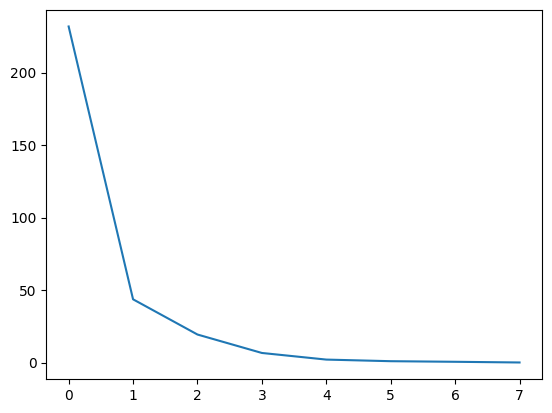

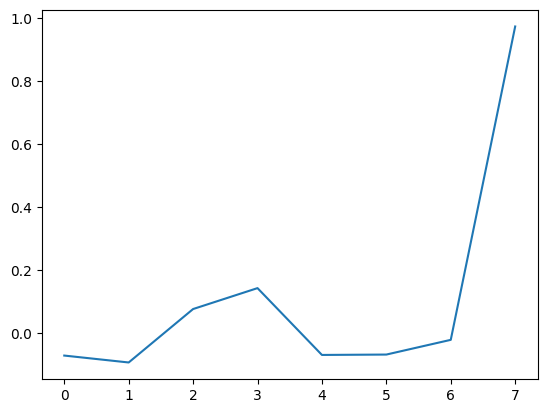

The parameter order is :K, p, mu, Rm, v, T, K_hat, r
GAS_score is [4.33718442e-03 1.42704559e-01 1.05727082e-02 2.17814159e-02
 4.10412117e-03 1.35013064e-02 3.97496800e-04 8.02601208e-01]
K is: 0.004337184421420003
p is: 0.14270455941813043
mu is: 0.010572708207601672
Rm is: 0.021781415863705328
v is: 0.004104121169526064
T is: 0.01350130639417232
K_hat is: 0.00039749680008240154
r is: 0.8026012077253618


/tmp/ipykernel_510/179211966.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


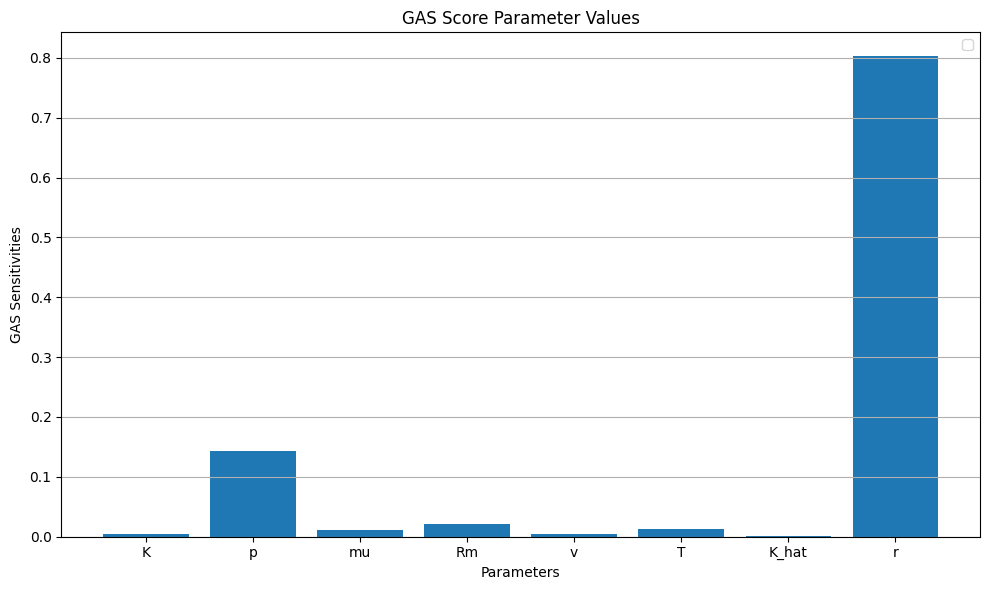

In [ ]:
start = time.perf_counter()
dim=8
chi=1000
M2 = 5
C = calc_C(
            f=Func,
            X=R.uniform(0, 1, (int(chi/2/M2), dim)),
            n_points=M2
        )
#print("55555",C.shape)
#u, s, _ = np.linalg.svd(C.T.astype(float), full_matrices=False)

#gas_values8 = GAS_score(8, u, s)
#gas_values = GAS_score(1, u, s)

C = 0.5 * (C + C.T)                 # 数值对称
s, u = np.linalg.eigh(C)            # s 升序，u 的第 i 列 ↔ s[i]

# 需要降序：
idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

# 交给 GAS
gas_values  = GAS_score(2, u, s)
end = time.perf_counter()
print("Time:", end - start, "seconds")

plt.plot(s)
plt.show()

plt.plot(u[:,0])
plt.show()

# Print the values
print("The parameter order is :K, p, mu, Rm, v, T, K_hat, r")
print("GAS_score is",gas_values)
print("K is:",gas_values[0])
print("p is:",gas_values[1])
print("mu is:",gas_values[2])
print("Rm is:",gas_values[3])
print("v is:",gas_values[4])
print("T is:",gas_values[5])
print("K_hat is:",gas_values[6])
print("r is:",gas_values[7])


# 参数标签
parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat", "r"]
x = np.arange(len(parameters))

# 绘制并排柱状图
plt.figure(figsize=(10, 6))
plt.bar(x, gas_values)

# 设置标签和样式
plt.xlabel("Parameters")
plt.ylabel("GAS Sensitivities")
plt.title("GAS Score Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-272/1029239671.py:93: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=False)
/usr/local/lib/python3.12/dist-packages/SALib/sample/saltelli.py:110: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (1000) is equal to `2^n`.
        
  warnings.warn(msg)


Time: 2045.7376260149995 seconds
Total Sobol Indices:
K: 0.0123
p: 0.0334
mu: 0.0344
Rm: 0.0562
v: 0.0103
T: 0.0339
K_hat: 0.0018
r: 0.9243


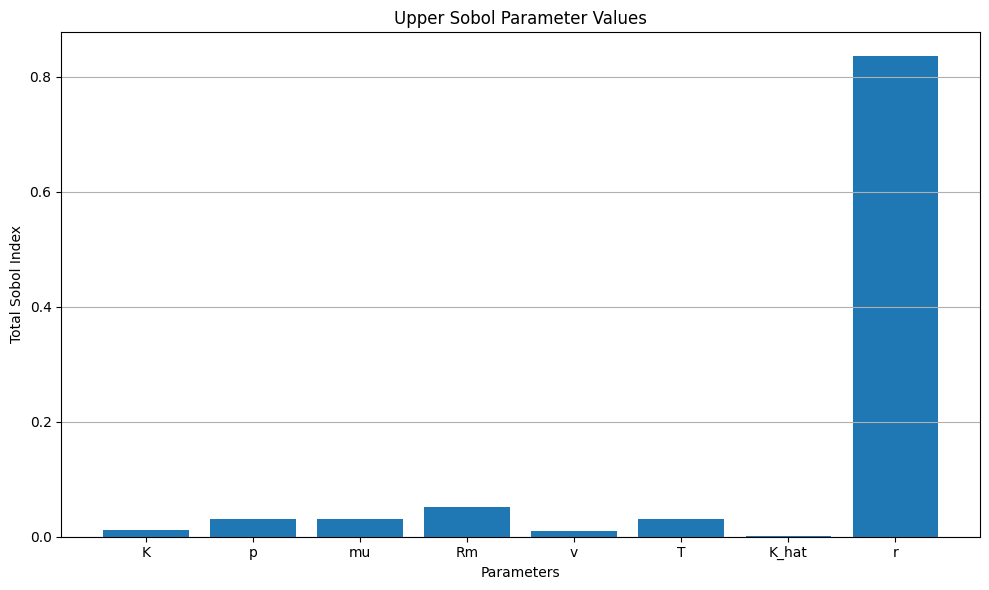

In [ ]:
import numpy as np
!pip install SALib
import time
import SALib
from SALib.sample import saltelli
from SALib.analyze import sobol
import matplotlib.pyplot as plt

def function1(parameters,n):
    K, p, mu, Rm, v, T, K_hat, r= parameters

    # Define the ODE systems
    def ode_system_1(t, B):
        val=(K * p / (mu * (Rm + v * B)))
        return val + np.random.normal(loc=0, scale=abs(val)*0.15)                      ## add noisy with N(0,#% of answer)
    def ode_system_2(t, B):
        val=(-K_hat * p * B / (mu * (Rm + v * B)))
        return val + np.random.normal(loc=0, scale=abs(val)*0.15)                      ## add noisy with N(0,#% of answer)

    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

start = time.perf_counter()

problem = {
    'num_vars': 8,
    'names': ['K', 'p', 'mu', 'Rm', 'v', 'T', 'K_hat', 'r'],
    'bounds': [
        [0.7 * 3.5, 1.3 * 3.5],    # K
        [0.7 * 2, 1.3 * 2],            # p
        [0.7 * 0.5, 1.3 * 0.5],  # mu
        [0.7 * 1, 1.3 * 1],  # Rm
        [0.7 * 1, 1.3 * 1],  # v
        [0.7 * 5, 1.3 * 5],            # T
        [0.7 * 43, 1.3 * 43],      # K_hat
        [0.7 * 0.7, 1.3 * 0.7]         # r
    ]
}

# Generate samples using Saltelli's sampling method
N = 1000  # Base sample size
param_values = saltelli.sample(problem, N, calc_second_order=False)

# Evaluate the model for each sample with n=10
Y = np.array([function1(params, n=10) for params in param_values])

# Perform Sobol sensitivity analysis
Si = sobol.analyze(problem, Y, calc_second_order=False)

end = time.perf_counter()
print("Time:", end - start, "seconds")

# Print Total Sobol Indices (upper indices)
print("Total Sobol Indices:")
for i, param in enumerate(problem['names']):
    print(f"{param}: {Si['ST'][i]:.4f}")

# Plot the total Sobol indices as a bar chart
parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat", "r"]
x = np.arange(len(parameters))

plt.figure(figsize=(10, 6))
plt.bar(x, Si['ST'])
plt.xlabel("Parameters")
plt.ylabel("Total Sobol Index")
plt.title("Upper Sobol Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 11.5 MB/s eta 0:00:00
                 vi         vi_std        dgsm     dgsm_conf
K      19375.700056  554404.303303  142.141711  35725.149305
p       2085.016894   47054.163613   15.295853   2709.999564
mu      9228.162470  137107.391831   67.698550   8728.076356
Rm      4418.605162  100077.869202   32.415247   6458.001810
v       3808.035438   87093.595112   27.936058   5498.115738
T       4537.079948  108500.754270   33.284387   7458.467249
K_hat   3130.885545   43803.685315   22.968431   2453.312500
r      17481.878269  349909.426066  128.248480  18735.502589
Time: 2862.014365079 seconds


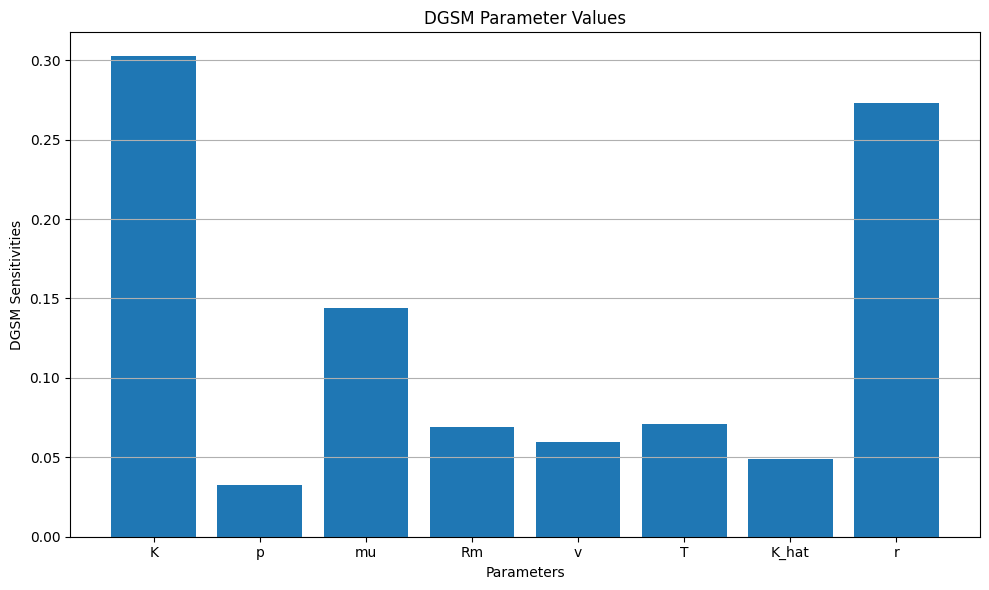

In [ ]:
import numpy as np
!pip install SALib
import SALib
import matplotlib.pyplot as plt
from SALib.analyze import dgsm
from SALib.sample import finite_diff


def function2(parameters,n):
    K, p, mu, Rm, v, T, K_hat, r= parameters
    #K=K*(1.3-0.7)*10**9+0.7*10**9
    #p=p*(1.3-0.7)*2+0.7*2
    #mu=mu*(1.3-0.7)*10**(-3)+0.7*10**(-3)
    #Rm=Rm*(1.3-0.7)*10**(-7)+0.7*10**(-7)
    #v=v*(1.3-0.7)*10**(-5)+0.7*10**(-5)
    #T=T*(1.3-0.7)*5+0.7*5
    #K_hat=K_hat*(1.3-0.7)*0.01+0.7*0.01
    #r=r*(1.3-0.7)*0.7+0.7*0.7

    K=K*(1.3-0.7)*3.5+0.7*3.5
    p=p*(1.3-0.7)*2+0.7*2
    mu=mu*(1.3-0.7)*0.5+0.7*0.5
    Rm=Rm*(1.3-0.7)*1+0.7*1
    v=v*(1.3-0.7)*1+0.7*1
    T=T*(1.3-0.7)*5+0.7*5
    K_hat=K_hat*(1.3-0.7)*43+0.7*43
    r=r*(1.3-0.7)*0.7+0.7*0.7

    # Define the ODE systems
    def ode_system_1(t, B):
        val=(K * p / (mu * (Rm + v * B)))
        return val + np.random.normal(loc=0, scale=abs(val)*0.05)                      ## add noisy with N(0,#% of answer)
    def ode_system_2(t, B):
        val=(-K_hat * p * B / (mu * (Rm + v * B)))
        return val + np.random.normal(loc=0, scale=abs(val)*0.05)                      ## add noisy with N(0,#% of answer)

    # Initialize
    B0 = 0.0  # Initial condition for B
    total_integrand_values = []
    total_time_points = []
    B_values = []  # Store B values over time

    # Interval length
    interval_length = T / n

    for i in range(n):
        # Time spans for the current interval
        t1_span = (i * interval_length, i * interval_length + r * interval_length)
        t2_span = (i * interval_length + r * interval_length, (i + 1) * interval_length)

        # Solve first ODE in the current interval
        t1_eval = np.linspace(t1_span[0], t1_span[1], 50)
        solution_1 = solve_ivp(ode_system_1, t1_span, [B0], t_eval=t1_eval, method='RK45')
        t1 = solution_1.t
        B1 = solution_1.y[0]

        # Solve second ODE in the current interval
        B1_final = B1[-1]  # Final value of B from the first ODE
        t2_eval = np.linspace(t2_span[0], t2_span[1], 50)
        solution_2 = solve_ivp(ode_system_2, t2_span, [B1_final], t_eval=t2_eval, method='RK45')
        t2 = solution_2.t
        B2 = solution_2.y[0]

        # Combine time and B values for this interval
        t_combined = np.concatenate((t1, t2))
        B_combined = np.concatenate((B1, B2))

        # Update the initial condition for the next interval using the final state of B2
        B0 = B2[-1]

        # Store results
        total_time_points.extend(t_combined)
        B_values.extend(B_combined)

        # Compute the integrand values
        integrand_1 = p / (mu * (Rm + v * np.array(B1)))  # First part
        integrand_2 = -p / (mu * (Rm + v * np.array(B2))) # Second part (negative)

        total_integrand_values.extend(integrand_1)
        total_integrand_values.extend(integrand_2)

    # Compute the final integral
    integral_simps = simpson(total_integrand_values, x=total_time_points)

    # Compute cumulative integral approximation
    cumulative_integral = np.cumsum(np.array(total_integrand_values) * np.gradient(total_time_points))

    return cumulative_integral[-1]

start = time.perf_counter()
# Define the parameter bounds
#bounds = np.array([
#    [0.7 * 3.5, 1.3 * 3.5],    # K
#    [0.7 * 2, 1.3 * 2],            # p
#    [0.7 * 0.5, 1.3 * 0.5],  # mu
#    [0.7 * 1, 1.3 * 1],  # Rm
#    [0.7 * 1, 1.3 * 1],  # v
#    [0.7 * 5, 1.3 * 5],            # T
#    [0.7 * 43, 1.3 * 43],      # K_hat
#    [0.7 * 0.7, 1.3 * 0.7]         # r
#])

#bounds = np.array([
#    [0.7 * 10**9, 1.3 * 10**9],    # K
#    [0.7 * 2, 1.3 * 2],            # p
#    [0.7 * 10**(-3), 1.3 * 10**(-3)],  # mu
#    [0.7 * 10**(-7), 1.3 * 10**(-7)],  # Rm
#    [0.7 * 10**(-5), 1.3 * 10**(-5)],  # v
#    [0.7 * 5, 1.3 * 5],            # T
#    [0.7 * 0.01, 1.3 * 0.01],      # K_hat
#    [0.7 * 0.7, 1.3 * 0.7]         # r
#])

bounds = np.array([
    [0,1],    # K
    [0,1],            # p
    [0,1],  # mu
    [0,1],  # Rm
    [0,1],  # v
    [0,1],            # T
    [0,1],      # K_hat
    [0,1]         # r
])

# Define the problem dictionary required by SALib
problem = {
    'num_vars': len(bounds),
    'names': ['K', 'p', 'mu', 'Rm', 'v', 'T', 'K_hat', 'r'],
    'bounds': bounds.tolist()
}

N=1000
# Generate samples using finite difference method
param_values = finite_diff.sample(problem, N)

# Compute the function output for each sample
Y = np.array([function2(params,n=10) for params in param_values])

# Perform DGSM analysis
dgsm_results = dgsm.analyze(problem, param_values, Y, print_to_console=True)

# Normalize
vi = dgsm_results['vi']
vi_normalized = vi / np.sum(vi)
end = time.perf_counter()
print("Time:", end - start, "seconds")

# Plot
parameters = ["K", "p", "mu", "Rm", "v", "T", "K_hat", "r"]
x = np.arange(len(parameters))

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x, vi_normalized)
plt.xlabel("Parameters")
plt.ylabel("DGSM Sensitivities")
plt.title("DGSM Parameter Values")
plt.xticks(x, parameters)
plt.grid(axis='y')
plt.tight_layout()
plt.show()